In [1]:
import sys
from pathlib import Path
prediction_mode_path = Path("./module")
sys.path.append(prediction_mode_path.as_posix())
import models_creation as pred_model

import pandas as pd
import numpy as np

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.model_selection import train_test_split
import math

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
#from sklearn import tree

from matplotlib import pyplot as plt

import joblib

from mordred import Calculator, descriptors
import mordred
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem import Draw

import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
molecular_descriptors_df_I = pred_model.prepare_data('QSPR_epoxidation_model_I.xlsx')

100%|██████████████████████████████████████████████████████████████████████████████████| 41/41 [00:01<00:00, 28.40it/s]


Data size (rows, columns): (41, 3874)
Data size after first reduction (rows, columns): (41, 3333)
Data size after second reduction (rows, columns): (41, 1279)


In [3]:
#molecular_descriptors_df_II = pred_model.prepare_data('QSPR_epoxidation_model_II.xlsx')

Data size after first reduction (rows, columns): (41, 1281)


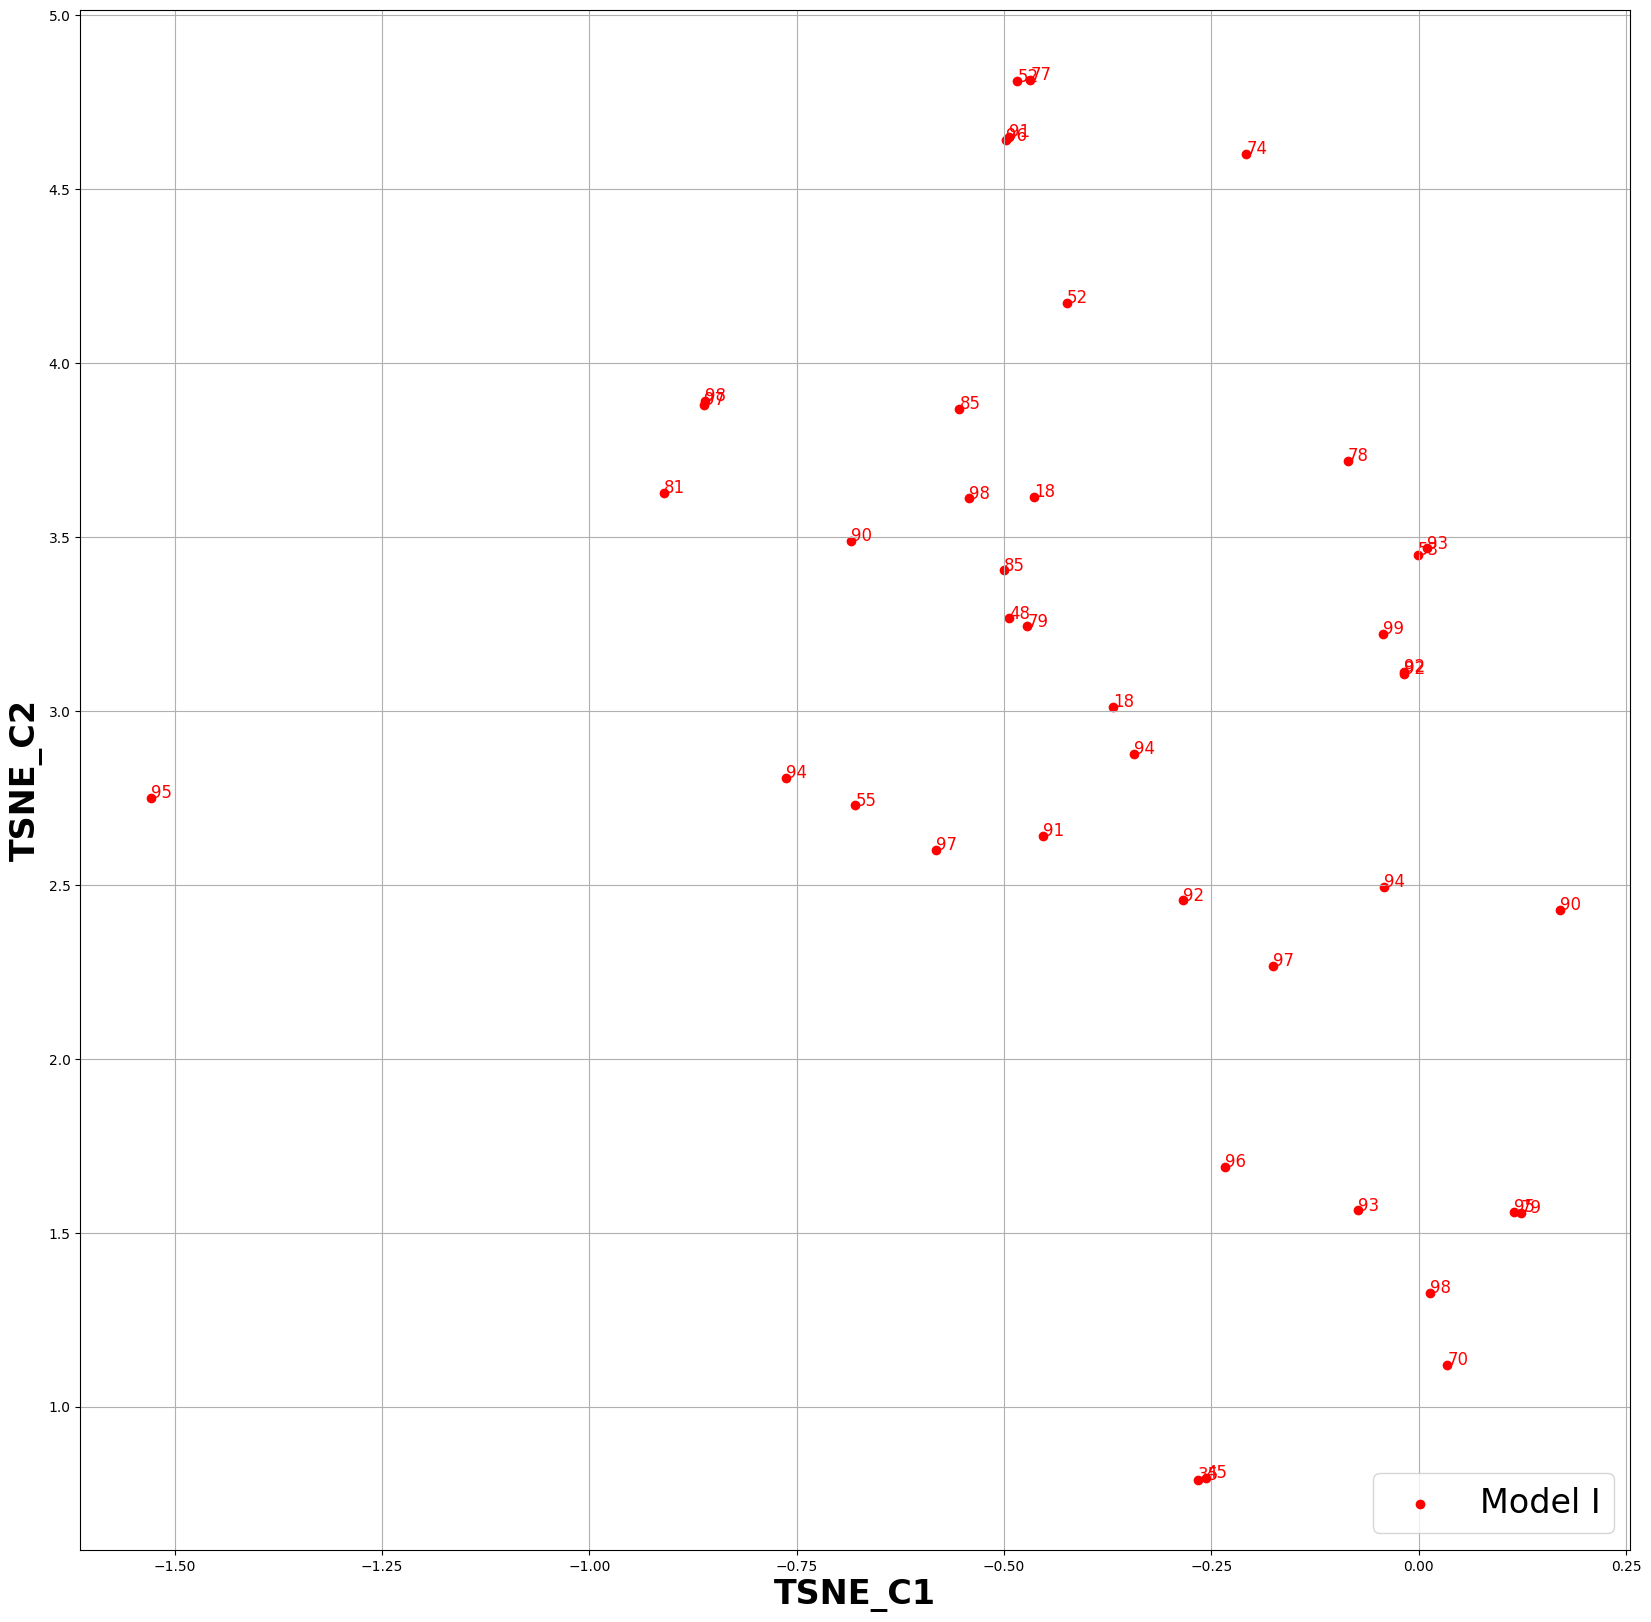

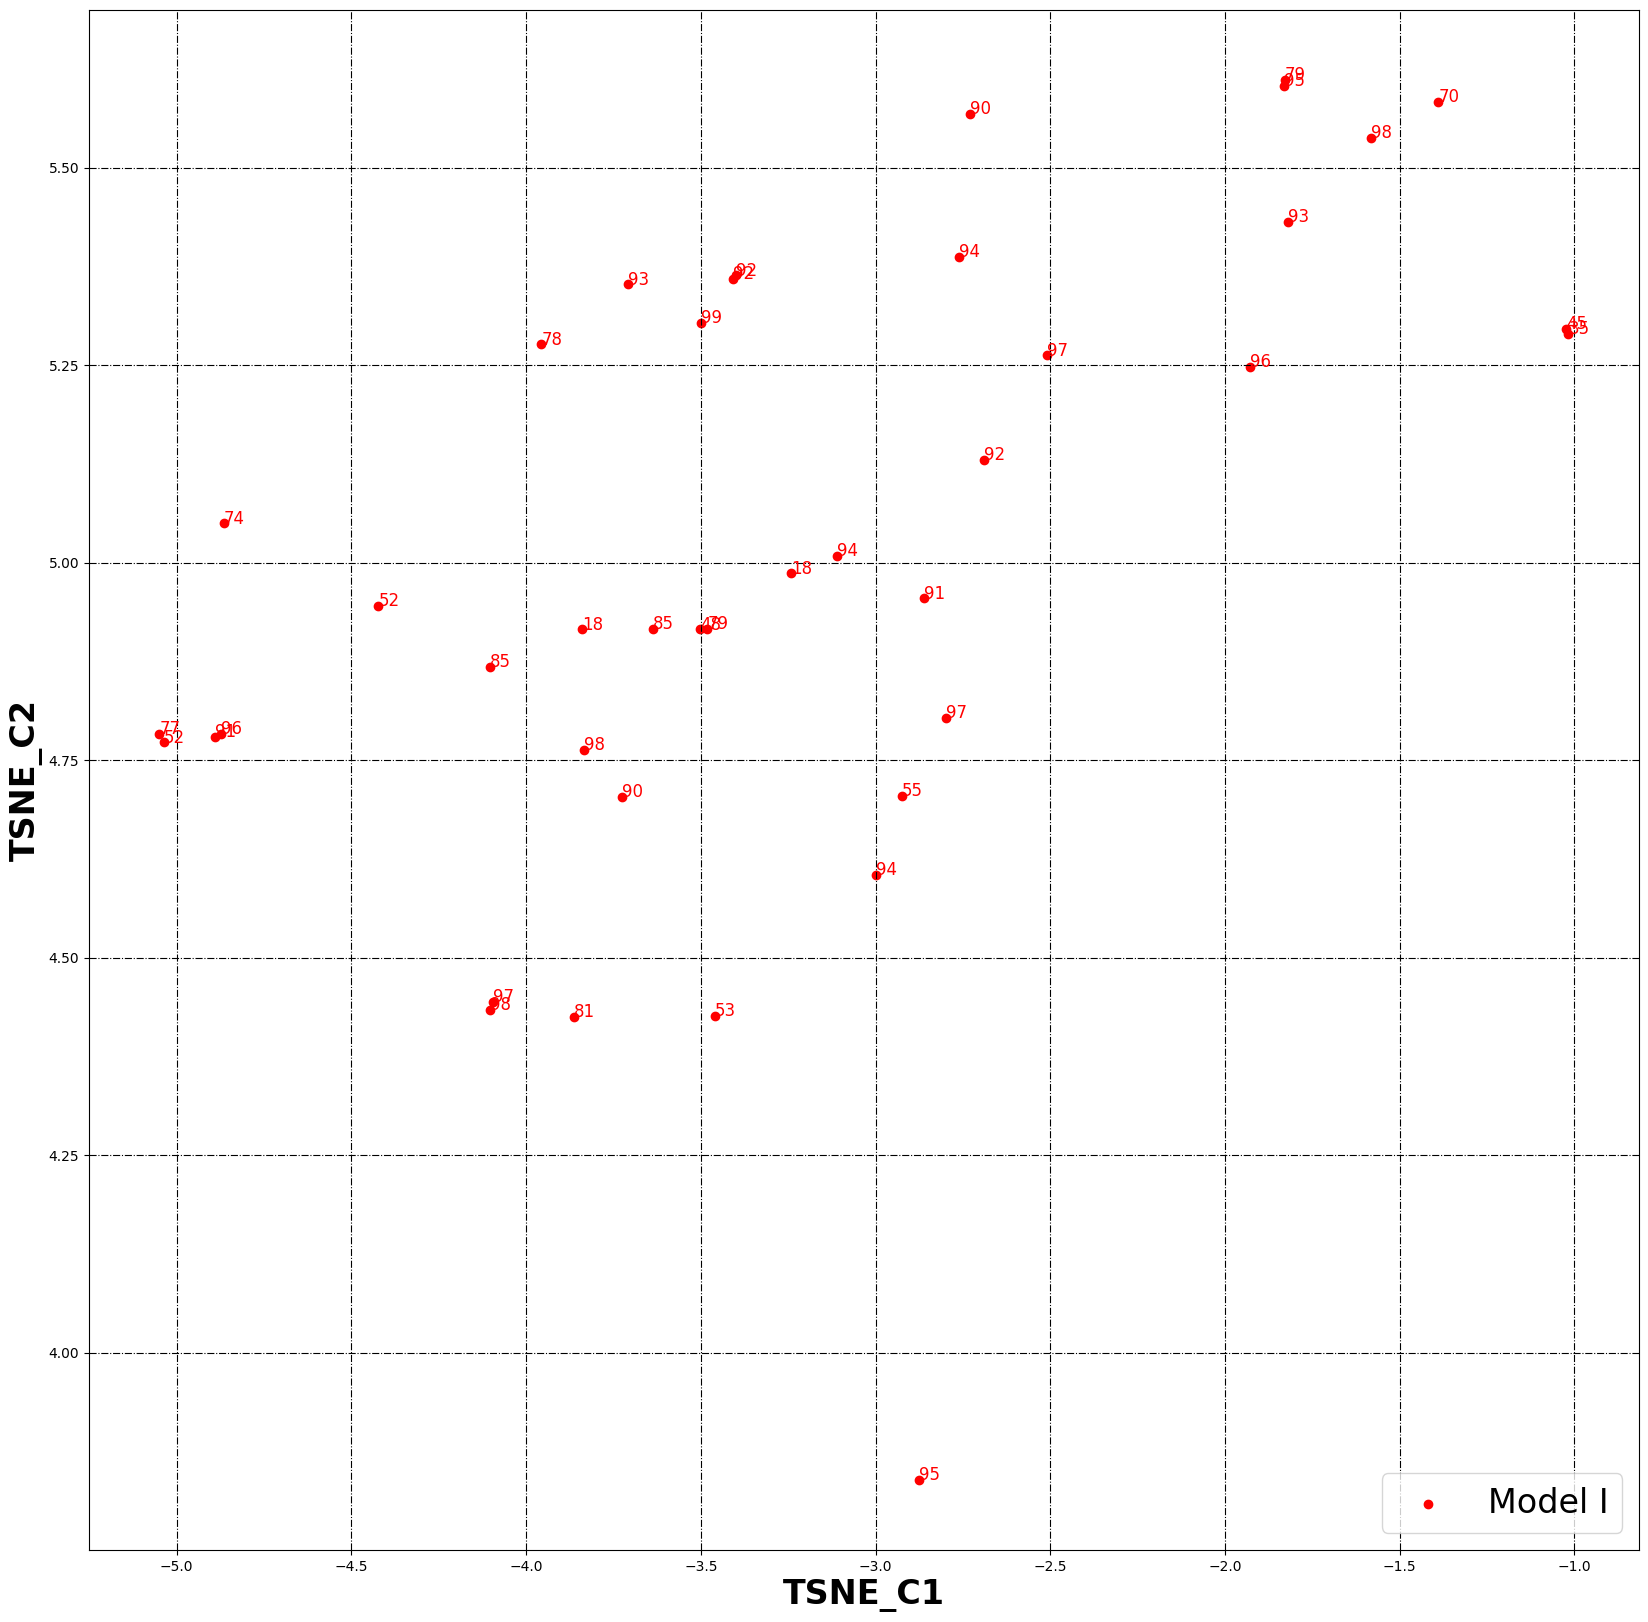

In [4]:

#First model
model_I = molecular_descriptors_df_I
model_I['Model'] = 'Model I'

#model_II = molecular_descriptors_df_II
#model_II['Model I / II'] = 'Model II'

# Concatenate DataFrames
whole_df = model_I# pd.concat([model_I, model_II], ignore_index=True)

simple_preprocessing = True #True
if simple_preprocessing:
    whole_df = whole_df.dropna(axis=1, how='any')
    print("Data size after first reduction (rows, columns): " + str(whole_df.shape))
        
whole_df_ = whole_df['ee'].copy()
whole_df__df = pd.DataFrame(data=whole_df_, columns=['ee'])
whole_df__ = whole_df.copy()

# t-SNE analysis
model = TSNE(n_components=2, random_state=0, perplexity=30, n_iter=10000, init='pca')
tsne_whole_set = model.fit_transform(whole_df.iloc[:,:-2])

whole_df['TSNE_C1'] = tsne_whole_set.T[0]
whole_df['TSNE_C2'] = tsne_whole_set.T[1]

test = whole_df.copy()

        
x_model_I = whole_df.loc[whole_df['Model'] == 'Model I']
#x_model_II = whole_df.loc[whole_df['Model'] == 'Model II']

fig = plt.figure(figsize=(20,20))
ax = fig.add_subplot(111)

ax.scatter(x_model_I['TSNE_C1'], x_model_I['TSNE_C2'], c='r', marker="o", label='Model I') #, alpha=1
#ax.scatter(x_model_II['TSNE_C1'], x_model_II['TSNE_C2'], c='b', marker="s", label='Model II', alpha=0.5)#, alpha=0.1
#for i, txt in enumerate(x_model_II.index):
 #   ax.annotate(whole_df__df['ee'][i+41], (x_model_II['TSNE_C1'][i+41], x_model_II['TSNE_C2'][i+41]), fontsize=12, color='blue')
for i, txt in enumerate(x_model_I.index):
    ax.annotate(whole_df__df['ee'][i], (x_model_I['TSNE_C1'][i], x_model_I['TSNE_C2'][i]), fontsize=12, color='red')
plt.legend(loc='lower right', fontsize=24)
plt.xlabel('TSNE_C1', fontweight='bold', fontsize=24)
plt.ylabel('TSNE_C2', fontweight='bold', fontsize=24)
plt.rc('grid', linestyle="-.", color='black')
plt.grid(True)
#plt.savefig('t-SNE_analysis_'+'_MODELI_'+'.svg', bbox_inches='tight')
        
# PCA analysis
pca = PCA(n_components=5, random_state=42) #n_components=20 in the case of activity_pred_app
pca_training_whole = pca.fit_transform(whole_df__.iloc[:,:-2])

list_pca = []
whole_data_II = pd.DataFrame(data=whole_df_, columns=['ee'])
for i in range(5):
    list_pca.append('PC'+str(i+1))
for pca_ in range(5):
    whole_data_II[list_pca[pca_]] = pca_training_whole.T[pca_]

        # t-SNE analysis
model = TSNE(n_components=2, random_state=0, perplexity=30, n_iter=10000, init='pca')
tsne_whole_set = model.fit_transform(pca_training_whole)

tsne_whole_set_PCA = tsne_whole_set.copy()

whole_df['TSNE_C1'] = tsne_whole_set.T[0]
whole_df['TSNE_C2'] = tsne_whole_set.T[1]
x_model_I = whole_df.loc[whole_df['Model'] == 'Model I']
#x_model_II = whole_df.loc[whole_df['Model I / II'] == 'Model II']

fig = plt.figure(figsize=(20,20))
ax = fig.add_subplot(111)

ax.scatter(x_model_I['TSNE_C1'], x_model_I['TSNE_C2'], c='r', marker="o", label='Model I') #, alpha=1
#ax.scatter(x_model_II['TSNE_C1'], x_model_II['TSNE_C2'], c='b', marker="s", label='Model II', alpha=0.5)#, alpha=0.1
#for i, txt in enumerate(x_model_II.index):
 #   ax.annotate(whole_data_II['ee'][i+41], (x_model_II['TSNE_C1'][i+41], x_model_II['TSNE_C2'][i+41]), fontsize=12, color='blue')
for i, txt in enumerate(x_model_I.index): #may be txt instead of whole_data_II
    ax.annotate(whole_data_II['ee'][i], (x_model_I['TSNE_C1'][i], x_model_I['TSNE_C2'][i]), fontsize=12, color='red')
plt.legend(loc='lower right', fontsize=24)
plt.xlabel('TSNE_C1', fontweight='bold', fontsize=24)
plt.ylabel('TSNE_C2', fontweight='bold', fontsize=24)
plt.rc('grid', linestyle="-.", color='black')
plt.grid(True)
#plt.savefig('t-SNE_analysis_'+'_PCA_5_MODEL_I'+'.svg', bbox_inches='tight')

In [5]:
whole_df.iloc[:,:-3]

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,C_FP_1979,C_FP_1985,C_FP_1991,C_FP_1992,C_FP_1996,C_FP_1999,C_FP_2029,C_FP_2033,C_FP_2041,ee
0,21.096774,5.806774,3.096774,6.451613,154.935746,83.174801,1.660974,5.923665,3.939068,7.356725,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,92
1,32.285714,5.973175,3.321429,7.128748,153.200722,131.707465,1.861423,6.164168,4.175784,7.587078,...,0.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,55
2,26.400000,6.438830,3.433333,10.000000,156.786781,104.641286,1.662128,6.517330,7.696296,7.908921,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,48
3,32.285714,5.973175,3.321429,7.128748,153.200722,131.707465,1.861423,6.164168,4.175784,7.587078,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,97
4,22.000000,5.860000,3.142857,6.857143,153.799230,86.861521,1.707574,5.980396,4.190476,7.395751,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,97
5,21.562500,5.820625,3.375000,6.687500,154.056327,85.083842,1.696221,5.941753,3.793403,7.362468,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,74
6,26.400000,6.438830,3.433333,10.000000,156.786781,104.641286,1.662128,6.517330,7.696296,7.908921,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,79
7,26.400000,6.438830,3.433333,10.000000,156.786781,104.641286,1.662128,6.517330,7.696296,7.908921,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,85
8,26.400000,6.438830,3.433333,10.000000,156.786781,104.641286,1.662128,6.517330,7.696296,7.908921,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18
9,65.714286,5.955271,3.321429,7.109543,152.179524,314.848419,2.023927,6.120454,4.151605,7.525876,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,95


In [6]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

df = whole_df.iloc[:,:-3]

# Compute cosine similarity matrix between rows
similarity_matrix = cosine_similarity(df.values)

# Convert similarity matrix back to DataFrame for easier interpretation (optional)
similarity_df = pd.DataFrame(similarity_matrix, index=df.index, columns=df.index)

print(similarity_df)

# Calculate overall average similarity excluding self-similarity on the diagonal
np.fill_diagonal(similarity_matrix, np.nan)
overall_similarity = np.nanmean(similarity_matrix)

print(f"Overall average similarity in dataset: {overall_similarity:.4f}")


          0         1         2         3         4         5         6    
0   1.000000  0.994126  0.997810  0.995830  0.998818  0.995137  0.998183  \
1   0.994126  1.000000  0.998315  0.998907  0.996216  0.989949  0.998091   
2   0.997810  0.998315  1.000000  0.998166  0.998223  0.993956  0.999789   
3   0.995830  0.998907  0.998166  1.000000  0.997442  0.990638  0.998473   
4   0.998818  0.996216  0.998223  0.997442  1.000000  0.994622  0.998445   
5   0.995137  0.989949  0.993956  0.990638  0.994622  1.000000  0.994277   
6   0.998183  0.998091  0.999789  0.998473  0.998445  0.994277  1.000000   
7   0.997218  0.997774  0.999232  0.998069  0.997666  0.994376  0.999473   
8   0.996155  0.997515  0.999001  0.996800  0.996408  0.994128  0.998911   
9   0.965572  0.979672  0.972282  0.980997  0.967904  0.958503  0.972697   
10  0.865362  0.849759  0.854201  0.856408  0.865889  0.855794  0.856436   
11  0.999871  0.994195  0.997911  0.995737  0.998859  0.995182  0.998152   
12  0.841760

In [7]:
# Find minimal similarity value (excluding diagonal)
min_similarity = np.nanmin(similarity_matrix)

print(f"Minimal similarity between any two rows: {min_similarity:.4f}")

Minimal similarity between any two rows: 0.8072


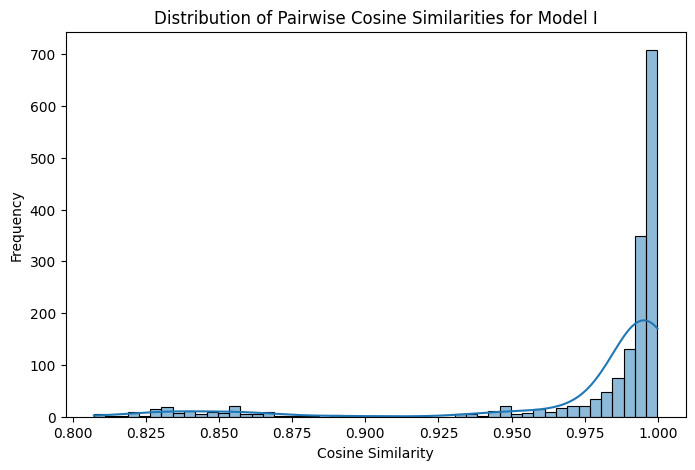

In [8]:
import seaborn as sns
# Remove diagonal values (self-similarity = 1)
np.fill_diagonal(similarity_matrix, np.nan)

# Flatten the matrix and remove nan values to get pairwise similarities
sim_values = similarity_matrix.flatten()
sim_values = sim_values[~np.isnan(sim_values)]

# Plot the distribution using seaborn
plt.figure(figsize=(8, 5))
sns.histplot(sim_values, bins=50, kde=True)
plt.title('Distribution of Pairwise Cosine Similarities for Model I')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
#plt.savefig('cosine_similarities_I.svg', bbox_inches='tight')
plt.show()

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Remove diagonal values (self-similarity = 1)
np.fill_diagonal(similarity_matrix, np.nan)

# Flatten the matrix and remove nan values to get pairwise similarities
sim_values = similarity_matrix.flatten()
sim_values = sim_values[~np.isnan(sim_values)]

# Set a clean font for better readability
plt.rcParams['font.family'] = 'Arial'  # Or 'Helvetica', 'sans-serif', etc.

# Create figure with specified size
plt.figure(figsize=(8, 5))

# Plot the distribution using seaborn
sns.histplot(sim_values, bins=50, kde=True)

# Customize font sizes for better visibility
plt.title('Distribution of Pairwise Cosine Similarities for Model I', fontsize=24, pad=15)
plt.xlabel('Cosine Similarity', fontsize=20)
plt.ylabel('Frequency', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=16)  # Larger tick labels

# Adjust layout to prevent clipping
plt.tight_layout(pad=1.5)  # Add padding to avoid text cutoff

# Save to file with high DPI and tight bounding box
plt.savefig('cosine_similarities_I.svg', bbox_inches='tight', format='svg', dpi=300)

# Show the plot (optional, comment out if only saving)
# plt.show()

# Close figure to free memory
plt.close()

In [10]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

scaler = StandardScaler()

# Assuming whole_df is your original DataFrame
df = whole_df.iloc[:, :-3]  # Select all columns except last 3

# Separate columns to standardize and those to keep as is
cols_to_standardize = [col for col in df.columns if "C_FP_" not in col]
cols_to_keep = [col for col in df.columns if "C_FP_" in col]

# Standardize only cols_to_standardize
df_standardized = pd.DataFrame(scaler.fit_transform(df[cols_to_standardize]), columns=cols_to_standardize, index=df.index)

# Keep the other columns as is
df_unchanged = df[cols_to_keep]

# Combine standardized and unchanged columns
df_final = pd.concat([df_standardized, df_unchanged], axis=1)

# Ensure original column order
df_final = df_final[df.columns]

# Compute cosine similarity matrix between rows
similarity_matrix = cosine_similarity(df_final.values)

# Convert similarity matrix back to DataFrame for easier interpretation (optional)
similarity_df = pd.DataFrame(similarity_matrix, index=df_final.index, columns=df_final.index)
print(similarity_df)

# Calculate overall average similarity excluding self-similarity
np.fill_diagonal(similarity_matrix, np.nan)
overall_similarity = np.nanmean(similarity_matrix)
print(f"Overall average similarity in dataset: {overall_similarity:.4f}")

          0         1         2         3         4         5         6    
0   1.000000  0.199663 -0.010010  0.515001  0.530878  0.356722  0.036051  \
1   0.199663  1.000000  0.185320  0.644097  0.491495  0.243217  0.144963   
2  -0.010010  0.185320  1.000000  0.090447 -0.055963  0.066017  0.890631   
3   0.515001  0.644097  0.090447  1.000000  0.491306  0.100997  0.181876   
4   0.530878  0.491495 -0.055963  0.491306  1.000000  0.233533 -0.046968   
5   0.356722  0.243217  0.066017  0.100997  0.233533  1.000000  0.062602   
6   0.036051  0.144963  0.890631  0.181876 -0.046968  0.062602  1.000000   
7   0.015424  0.084339  0.747536  0.169060 -0.040154  0.081581  0.866689   
8  -0.110669  0.228611  0.837068  0.006399 -0.045591  0.152768  0.785078   
9   0.301092  0.374183  0.020664  0.659422  0.203517  0.053958  0.069901   
10  0.031354 -0.081782 -0.375140 -0.068193  0.185448 -0.206860 -0.391762   
11  0.947574  0.206332  0.017576  0.474774  0.529114  0.344689  0.037027   
12 -0.020954

In [11]:
# Find minimal similarity value (excluding diagonal)
min_similarity = np.nanmin(similarity_matrix)

print(f"Minimal similarity between any two rows: {min_similarity:.4f}")

Minimal similarity between any two rows: -0.5908


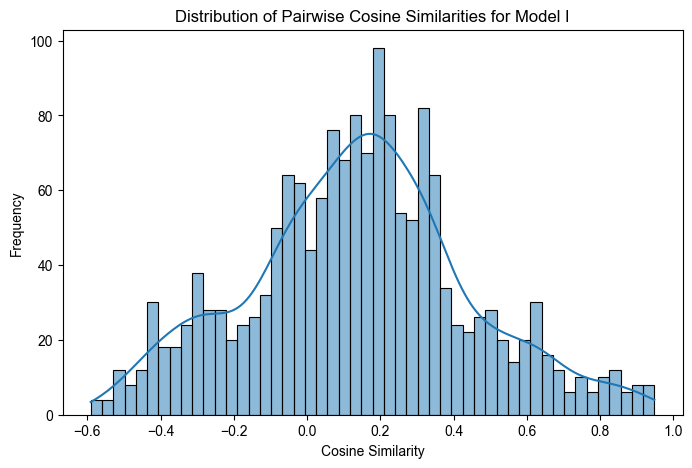

In [12]:
import seaborn as sns
# Remove diagonal values (self-similarity = 1)
np.fill_diagonal(similarity_matrix, np.nan)

# Flatten the matrix and remove nan values to get pairwise similarities
sim_values = similarity_matrix.flatten()
sim_values = sim_values[~np.isnan(sim_values)]

# Plot the distribution using seaborn
plt.figure(figsize=(8, 5))
sns.histplot(sim_values, bins=50, kde=True)
plt.title('Distribution of Pairwise Cosine Similarities for Model I')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
#plt.savefig('cosine_similarities_I.svg', bbox_inches='tight')
plt.show()

In [13]:
import numpy as np
from scipy.spatial.distance import pdist

# Assuming tsne_results is a numpy array of shape (n_samples, n_components)
distances = pdist(df_final, metric='euclidean')  # pairwise distances in condensed form
average_distance = distances.mean()

print("Average distance between points:", average_distance)

Average distance between points: 44.12601838208225


In [14]:
distances.min()

6.686193016670878

In [15]:
distances.max()

100.10147986498092

array([[<Axes: title={'center': 'distance'}>]], dtype=object)

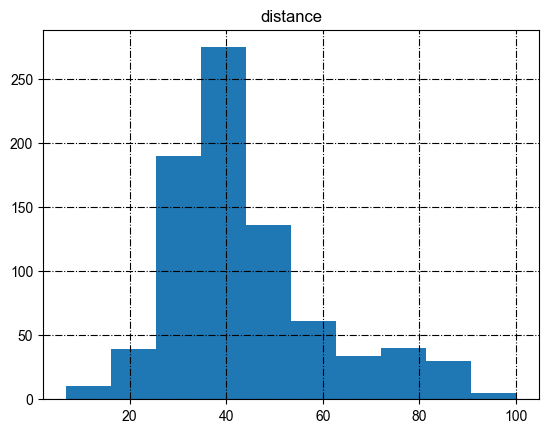

In [16]:
pd.DataFrame(data=distances, columns=['distance']).hist(bins=10)

In [17]:
df_final

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,C_FP_1979,C_FP_1985,C_FP_1991,C_FP_1992,C_FP_1996,C_FP_1999,C_FP_2029,C_FP_2033,C_FP_2041,ee
0,-0.570233,-0.789108,-0.383263,-0.652652,-0.285739,-0.513664,-0.225875,-0.803154,-0.714403,-0.862158,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.569344
1,0.846334,-0.273366,0.247409,-0.292940,-0.748457,0.732410,1.032703,-0.022006,-0.581160,0.005019,...,0.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,-1.104483
2,0.101178,1.169885,0.561559,1.232344,0.207918,0.037487,-0.218624,1.125056,1.400464,1.216612,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.421152
3,0.846334,-0.273366,0.247409,-0.292940,-0.748457,0.732410,1.032703,-0.022006,-0.581160,0.005019,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.795536
4,-0.455881,-0.624140,-0.253895,-0.437224,-0.588839,-0.419007,0.066715,-0.618890,-0.572890,-0.715242,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.795536
5,-0.511270,-0.746179,0.397800,-0.527343,-0.520274,-0.464649,-0.004562,-0.744403,-0.796395,-0.840536,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.244950
6,0.101178,1.169885,0.561559,1.232344,0.207918,0.037487,-0.218624,1.125056,1.400464,1.216612,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.018757
7,0.101178,1.169885,0.561559,1.232344,0.207918,0.037487,-0.218624,1.125056,1.400464,1.216612,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.252674
8,0.101178,1.169885,0.561559,1.232344,0.207918,0.037487,-0.218624,1.125056,1.400464,1.216612,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.778309
9,5.078531,-0.328856,0.247409,-0.303142,-1.020803,5.434545,2.053027,-0.163989,-0.594770,-0.225380,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.705059


In [18]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


# Assuming whole_df is your original DataFrame
df = whole_df.iloc[:, :-3]  # Select all columns except last 3

# Separate columns to standardize and those to keep as is
cols_to_standardize = [col for col in df.columns if "C_FP_" not in col]
cols_to_keep = [col for col in df.columns if "C_FP_" in col]


# Keep the other columns as is
df_unchanged = df[cols_to_keep]

# Ensure original column order
df_final = df_unchanged

# Compute cosine similarity matrix between rows
similarity_matrix = cosine_similarity(df_final.values)

# Convert similarity matrix back to DataFrame for easier interpretation (optional)
similarity_df = pd.DataFrame(similarity_matrix, index=df_final.index, columns=df_final.index)
print(similarity_df)

# Calculate overall average similarity excluding self-similarity
np.fill_diagonal(similarity_matrix, np.nan)
overall_similarity = np.nanmean(similarity_matrix)
print(f"Overall average similarity in dataset: {overall_similarity:.4f}")

          0         1         2         3         4         5         6    
0   1.000000  0.896567  0.895360  0.953757  0.906287  0.805789  0.940695  \
1   0.896567  1.000000  0.867692  0.908061  0.949080  0.849891  0.890229   
2   0.895360  0.867692  1.000000  0.895360  0.893747  0.816654  0.955556   
3   0.953757  0.908061  0.895360  1.000000  0.906287  0.805789  0.940695   
4   0.906287  0.949080  0.893747  0.906287  1.000000  0.868787  0.893747   
5   0.805789  0.849891  0.816654  0.805789  0.868787  1.000000  0.795303   
6   0.940695  0.890229  0.955556  0.940695  0.893747  0.795303  1.000000   
7   0.902399  0.914936  0.925420  0.902399  0.930822  0.827604  0.937061   
8   0.884791  0.958167  0.895041  0.884791  0.946335  0.854620  0.906091   
9   0.953757  0.896567  0.895360  0.953757  0.906287  0.805789  0.940695   
10  0.241921  0.213809  0.223995  0.215041  0.187033  0.392437  0.223995   
11  0.953757  0.873578  0.940695  0.907514  0.906287  0.827567  0.895360   
12  0.267835

In [19]:
df_final.head()

,C_FP_1,C_FP_12,C_FP_14,C_FP_21,C_FP_25,C_FP_31,C_FP_34,C_FP_39,C_FP_45,C_FP_79,...,C_FP_1972,C_FP_1979,C_FP_1985,C_FP_1991,C_FP_1992,C_FP_1996,C_FP_1999,C_FP_2029,C_FP_2033,C_FP_2041
0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [20]:
# Find minimal similarity value (excluding diagonal)
min_similarity = np.nanmin(similarity_matrix)

print(f"Minimal similarity between any two rows: {min_similarity:.4f}")

Minimal similarity between any two rows: 0.0239


In [21]:
# Find maximal similarity value (excluding diagonal)
min_similarity = np.nanmax(similarity_matrix)

print(f"Maximal similarity between any two rows: {min_similarity:.4f}")

Maximal similarity between any two rows: 0.9707


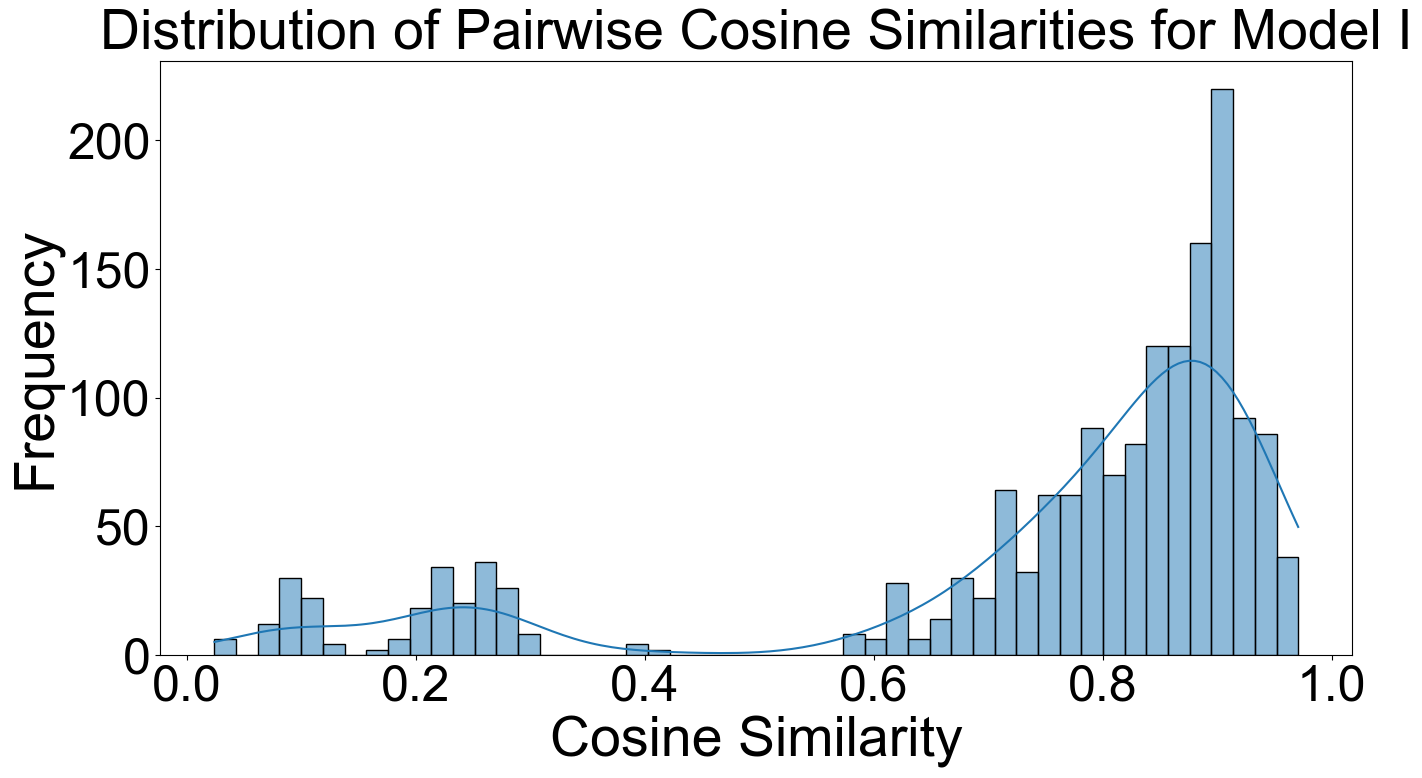

In [22]:
import seaborn as sns
# Remove diagonal values (self-similarity = 1)
np.fill_diagonal(similarity_matrix, np.nan)

# Flatten the matrix and remove nan values to get pairwise similarities
sim_values = similarity_matrix.flatten()
sim_values = sim_values[~np.isnan(sim_values)]

# Plot the distribution using seaborn
plt.figure(figsize=(14, 8))
sns.histplot(sim_values, bins=50, kde=True)
plt.title('Distribution of Pairwise Cosine Similarities for Model I', fontsize=40)
plt.xlabel('Cosine Similarity', fontsize=40)
plt.ylabel('Frequency', fontsize=40)
plt.tick_params(axis='both', which='major', labelsize=36)  # Larger tick labels

# Adjust layout to prevent clipping
plt.tight_layout(pad=1.5)  # Add padding to avoid text cutoff
plt.savefig('cosine_similarities_I.svg', bbox_inches='tight')
plt.show()

In [23]:
import numpy as np
from scipy.spatial.distance import pdist

# Assuming tsne_results is a numpy array of shape (n_samples, n_components)
distances = pdist(df_final, metric='euclidean')  # pairwise distances in condensed form; df_final; whole_df.iloc[:,-2:]
average_distance = distances.mean()

print("Average distance between points:", average_distance)

Average distance between points: 8.531580102627297


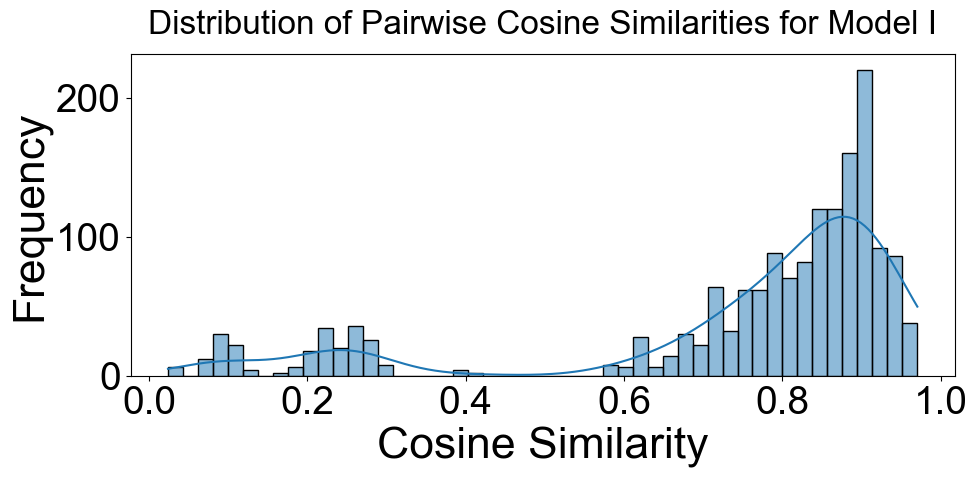

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Remove diagonal values (self-similarity = 1)
np.fill_diagonal(similarity_matrix, np.nan)

# Flatten the matrix and remove nan values to get pairwise similarities
sim_values = similarity_matrix.flatten()
sim_values = sim_values[~np.isnan(sim_values)]

# Set a clean font for better readability
plt.rcParams['font.family'] = 'Arial'  # Or 'Helvetica', 'sans-serif', etc.

# Create figure with specified size
plt.figure(figsize=(10, 5))

# Plot the distribution using seaborn
sns.histplot(sim_values, bins=50, kde=True)

# Customize font sizes for better visibility
plt.title('Distribution of Pairwise Cosine Similarities for Model I', fontsize=24, pad=15)
plt.xlabel('Cosine Similarity', fontsize=32)
plt.ylabel('Frequency', fontsize=32)
plt.tick_params(axis='both', which='major', labelsize=28)  # Larger tick labels

# Adjust layout to prevent clipping
plt.tight_layout(pad=1.5)  # Add padding to avoid text cutoff

# Save to file with high DPI and tight bounding box
plt.savefig('cosine_similarities_I.svg', bbox_inches='tight', format='svg', dpi=300)

# Show the plot (optional, comment out if only saving)
plt.show()

# Close figure to free memory
plt.close()

In [25]:
whole_df.iloc[:,-2:]

,TSNE_C1,TSNE_C2
0,-3.398769,5.363540
1,-2.925525,4.704391
2,-3.501555,4.915523
3,-2.799394,4.803651
4,-2.508239,5.262470
5,-4.864768,5.049893
6,-3.480827,4.915884
7,-3.637282,4.915891
8,-3.839751,4.915623
9,-2.875221,3.839146


In [26]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

df = whole_df.iloc[:,-2:]

# Compute cosine similarity matrix between rows
similarity_matrix = cosine_similarity(df.values)

# Convert similarity matrix back to DataFrame for easier interpretation (optional)
similarity_df = pd.DataFrame(similarity_matrix, index=df.index, columns=df.index)

print(similarity_df)

# Calculate overall average similarity excluding self-similarity on the diagonal
np.fill_diagonal(similarity_matrix, np.nan)
overall_similarity = np.nanmean(similarity_matrix)

print(f"Overall average similarity in dataset: {overall_similarity:.4f}")

          0         1         2         3         4         5         6    
0   1.000000  0.999964  0.998534  0.999309  0.992804  0.979685  0.998684  \
1   0.999964  1.000000  0.998040  0.999588  0.993782  0.977951  0.998214   
2   0.998534  0.998040  1.000000  0.995834  0.984867  0.989103  0.999996   
3   0.999309  0.999588  0.995834  1.000000  0.996568  0.971556  0.996089   
4   0.992804  0.993782  0.984867  0.996568  1.000000  0.948619  0.985355   
5   0.979685  0.977951  0.989103  0.971556  0.948619  1.000000  0.988681   
6   0.998684  0.998214  0.999996  0.996089  0.985355  0.988681  1.000000   
7   0.997395  0.996749  0.999837  0.994026  0.981580  0.991598  0.999782   
8   0.995171  0.994304  0.999025  0.990837  0.976255  0.994638  0.998896   
9   0.996960  0.996264  0.999716  0.993376  0.980455  0.992332  0.999644   
10  0.930844  0.933906  0.909703  0.943780  0.967905  0.838653  0.910878   
11  0.999999  0.999950  0.998613  0.999253  0.992625  0.979981  0.998759   
12  0.930550

In [27]:
from sklearn.metrics.pairwise import euclidean_distances
import numpy as np
import pandas as pd

df = whole_df['ee'].values.reshape(-1, 1)

# Calculate Euclidean distance matrix
distance_matrix = euclidean_distances(df)

print(distance_matrix)

# Optionally convert distance to similarity (e.g. similarity = 1 / (1 + distance))
similarity_matrix = 1 / (1 + distance_matrix)

print(similarity_matrix)

# Calculate overall average similarity excluding self-similarity on the diagonal
np.fill_diagonal(similarity_matrix, np.nan)
overall_similarity = np.nanmean(similarity_matrix)

print(f"Overall average similarity in dataset: {overall_similarity:.4f}")

[[ 0. 37. 44. ... 11. 74. 22.]
 [37.  0.  7. ... 26. 37. 15.]
 [44.  7.  0. ... 33. 30. 22.]
 ...
 [11. 26. 33. ...  0. 63. 11.]
 [74. 37. 30. ... 63.  0. 52.]
 [22. 15. 22. ... 11. 52.  0.]]
[[1.         0.02631579 0.02222222 ... 0.08333333 0.01333333 0.04347826]
 [0.02631579 1.         0.125      ... 0.03703704 0.02631579 0.0625    ]
 [0.02222222 0.125      1.         ... 0.02941176 0.03225806 0.04347826]
 ...
 [0.08333333 0.03703704 0.02941176 ... 1.         0.015625   0.08333333]
 [0.01333333 0.02631579 0.03225806 ... 0.015625   1.         0.01886792]
 [0.04347826 0.0625     0.04347826 ... 0.08333333 0.01886792 1.        ]]
Overall average similarity in dataset: 0.1439


In [28]:
type(whole_df['ee'])

pandas.core.series.Series

In [29]:
df

array([[92],
       [55],
       [48],
       [97],
       [97],
       [74],
       [79],
       [85],
       [18],
       [95],
       [45],
       [92],
       [35],
       [96],
       [52],
       [92],
       [53],
       [93],
       [95],
       [97],
       [96],
       [98],
       [98],
       [94],
       [91],
       [94],
       [99],
       [98],
       [93],
       [91],
       [85],
       [90],
       [78],
       [94],
       [77],
       [90],
       [79],
       [52],
       [81],
       [18],
       [70]], dtype=int64)

In [30]:
whole_df.iloc[:,-2:]

,TSNE_C1,TSNE_C2
0,-3.398769,5.363540
1,-2.925525,4.704391
2,-3.501555,4.915523
3,-2.799394,4.803651
4,-2.508239,5.262470
5,-4.864768,5.049893
6,-3.480827,4.915884
7,-3.637282,4.915891
8,-3.839751,4.915623
9,-2.875221,3.839146


In [31]:
import numpy as np
from scipy.spatial.distance import pdist

# Assuming tsne_results is a numpy array of shape (n_samples, n_components)
distances = pdist(whole_df.iloc[:,-2:], metric='euclidean')  # pairwise distances in condensed form
average_distance = distances.mean()

print("Average distance between points:", average_distance)

Average distance between points: 1.3759086567647068


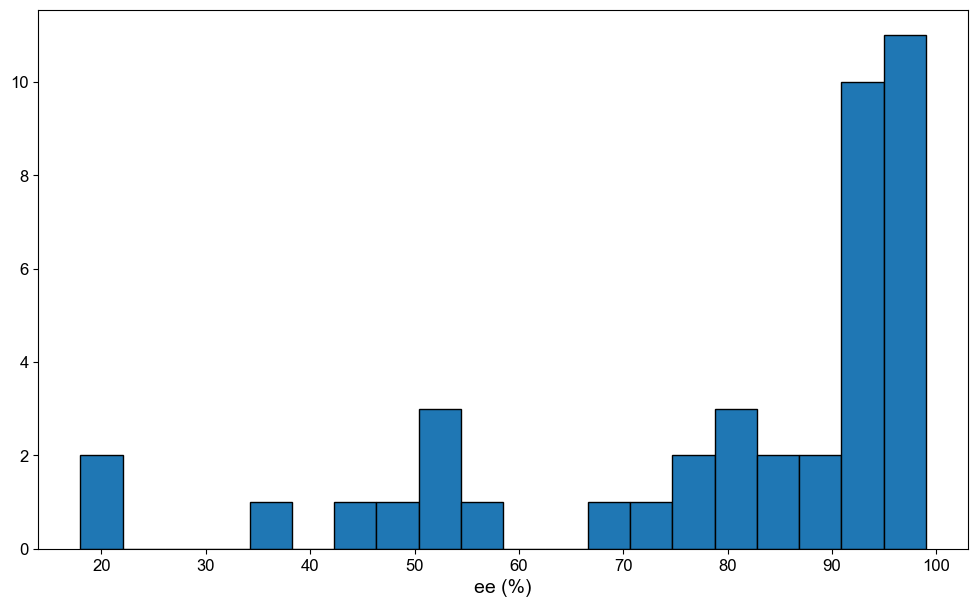

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Example DataFrame with column 'ee'
df = whole_df

plt.figure(figsize=(12, 7))  # Set a large figure size for better visibility
plt.hist(df['ee'], bins=20, edgecolor='black')  # Histogram of 'ee' column with bin edges outlined
#plt.title('Histogram of ee for model I', fontsize=18)
plt.xlabel('ee (%)', fontsize=14)
#plt.ylabel('Frequency', fontsize=14)
#plt.grid(True, linestyle='--', alpha=0.6)  # Optional grid for readability
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('ee_distribution_I.svg', bbox_inches='tight')
plt.show()


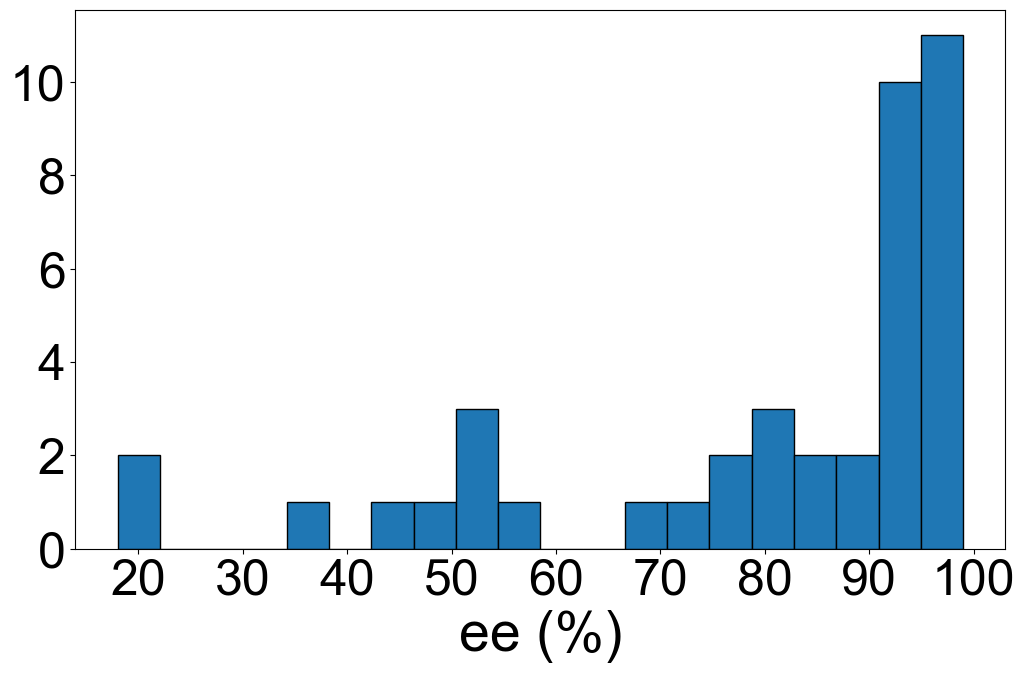

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Example DataFrame with column 'ee'
df = whole_df

plt.figure(figsize=(12, 7))  # Set a large figure size for better visibility
plt.hist(df['ee'], bins=20, edgecolor='black')  # Histogram of 'ee' column with bin edges outlined
#plt.title('Histogram of ee for model I', fontsize=18)
plt.xlabel('ee (%)', fontsize=40)
#plt.ylabel('Frequency', fontsize=14)
#plt.grid(True, linestyle='--', alpha=0.6)  # Optional grid for readability
plt.xticks(fontsize=36)
plt.yticks(fontsize=36)
plt.savefig('ee_distribution_I.svg', bbox_inches='tight')
plt.show()